# OSRS NPC Classification -- Champion vs. Challenger

Head-to-head comparison, both models evaluated on the **identical held-out test split**
(`npc_data.stratified_split`, `random_state=42`):

| | Champion (`03a`/`04a`) | Challenger (`03b`/`04b`) |
|---|---|---|
| Backbone | 2x pretrained ResNet18 (ImageNet) | 2x from-scratch 5-block CNN |
| Fusion head | Linear(1024->256)->ReLU->Dropout->Linear(256->11) | identical |
| Loss / optimizer | class-weighted CE, Adam lr=5e-5 | class-weighted CE, Adam lr=1e-3, weight_decay=1e-4 |

Only the backbone differs, so any gap in the numbers below is attributable to the
transfer-learning-vs-from-scratch choice rather than confounded by data or architecture-shape
differences elsewhere.

In [1]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

from npc_data import load_clean_npc_df, add_top_class_labels, stratified_split, get_transforms, NPCDataset
import eval_utils as eu

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [2]:
df = load_clean_npc_df(data_dir="../data")
df, CLASS_NAMES, class_to_idx = add_top_class_labels(df, n=10)
train_df, val_df, test_df = stratified_split(df, seed=42)

_, eval_transform = get_transforms(img_size=128)
test_loader = DataLoader(NPCDataset(test_df, eval_transform, data_dir="../data"), batch_size=32)
print(f"Test set: {len(test_df)} NPCs, {len(CLASS_NAMES)} classes")

Test set: 519 NPCs, 11 classes


## Load both models

In [3]:
class DualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = models.resnet18(weights=None)
        self.body_cnn = models.resnet18(weights=None)
        self.chathead_cnn.fc = nn.Identity()
        self.body_cnn.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        return self.classifier(torch.cat([self.chathead_cnn(chathead), self.body_cnn(body)], dim=1))


def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1), nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True), nn.MaxPool2d(2),
    )


class ScratchCNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
            conv_block(128, 256), conv_block(256, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        return self.pool(self.features(x)).flatten(1)


class ScratchDualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = ScratchCNNBackbone()
        self.body_cnn = ScratchCNNBackbone()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        return self.classifier(torch.cat([self.chathead_cnn(chathead), self.body_cnn(body)], dim=1))


champion = DualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
champion.load_state_dict(torch.load("../data/npc_classifier.pth", map_location=DEVICE))
champion.eval()

challenger = ScratchDualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
challenger.load_state_dict(torch.load("../data/custom_cnn_classifier.pth", map_location=DEVICE))
challenger.eval()

print("Both models loaded.")

Both models loaded.


## Headline metrics

In [4]:
champ_labels, champ_preds, champ_probs = eu.get_predictions(champion, test_loader, DEVICE)
chal_labels, chal_preds, chal_probs = eu.get_predictions(challenger, test_loader, DEVICE)
assert (champ_labels == chal_labels).all(), "test set order mismatch between models"

def summarize(y_true, y_pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

summary_df = pd.DataFrame([
    summarize(champ_labels, champ_preds, "Champion (pretrained ResNet18 x2)"),
    summarize(chal_labels, chal_preds, "Challenger (from-scratch CNN x2)"),
]).set_index("model")
summary_df.round(4)

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
model,,,,,
Champion (pretrained ResNet18 x2),0.8439,0.8447,0.8411,0.9218,0.7982
Challenger (from-scratch CNN x2),0.6185,0.4731,0.6385,0.4163,0.6776


## Per-class F1: champion vs. challenger

In [5]:
per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support": [int((champ_labels == i).sum()) for i in range(len(CLASS_NAMES))],
    "champion_f1": f1_score(champ_labels, champ_preds, average=None, labels=range(len(CLASS_NAMES)), zero_division=0),
    "challenger_f1": f1_score(chal_labels, chal_preds, average=None, labels=range(len(CLASS_NAMES)), zero_division=0),
})
per_class["champion_minus_challenger"] = per_class["champion_f1"] - per_class["challenger_f1"]
per_class.sort_values("support", ascending=False)

,class,support,champion_f1,challenger_f1,champion_minus_challenger
0,Human,314,0.888208,0.761221,0.126987
10,Other,86,0.697143,0.394161,0.302982
1,Dwarf,37,0.774194,0.456522,0.317672
2,Elf,22,0.777778,0.483871,0.293907
3,Gnome,21,0.820513,0.666667,0.153846
4,Vampyre,9,1.000000,0.857143,0.142857
5,Ghost,8,0.666667,0.153846,0.512821
6,Monkey,6,1.000000,0.303030,0.696970
7,Dorgeshuun,6,1.000000,0.521739,0.478261
8,Troll,5,1.000000,0.333333,0.666667


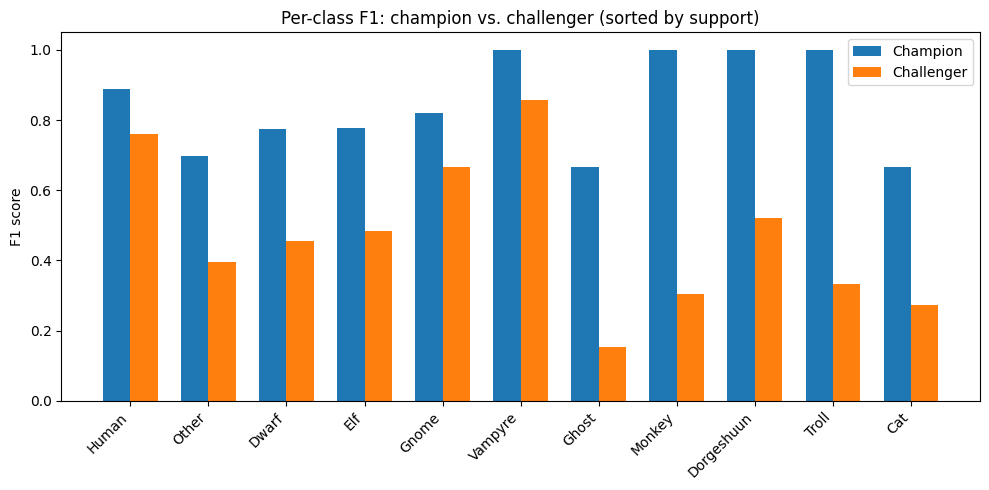

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES))
width = 0.35
order = per_class.sort_values("support", ascending=False).index
ax.bar(x - width/2, per_class.loc[order, "champion_f1"], width, label="Champion")
ax.bar(x + width/2, per_class.loc[order, "challenger_f1"], width, label="Challenger")
ax.set_xticks(x)
ax.set_xticklabels(per_class.loc[order, "class"], rotation=45, ha="right")
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: champion vs. challenger (sorted by support)")
ax.legend()
plt.tight_layout()
plt.savefig("../img/classification_per_class_f1_comparison.png")
plt.show()

## Confusion matrices side by side

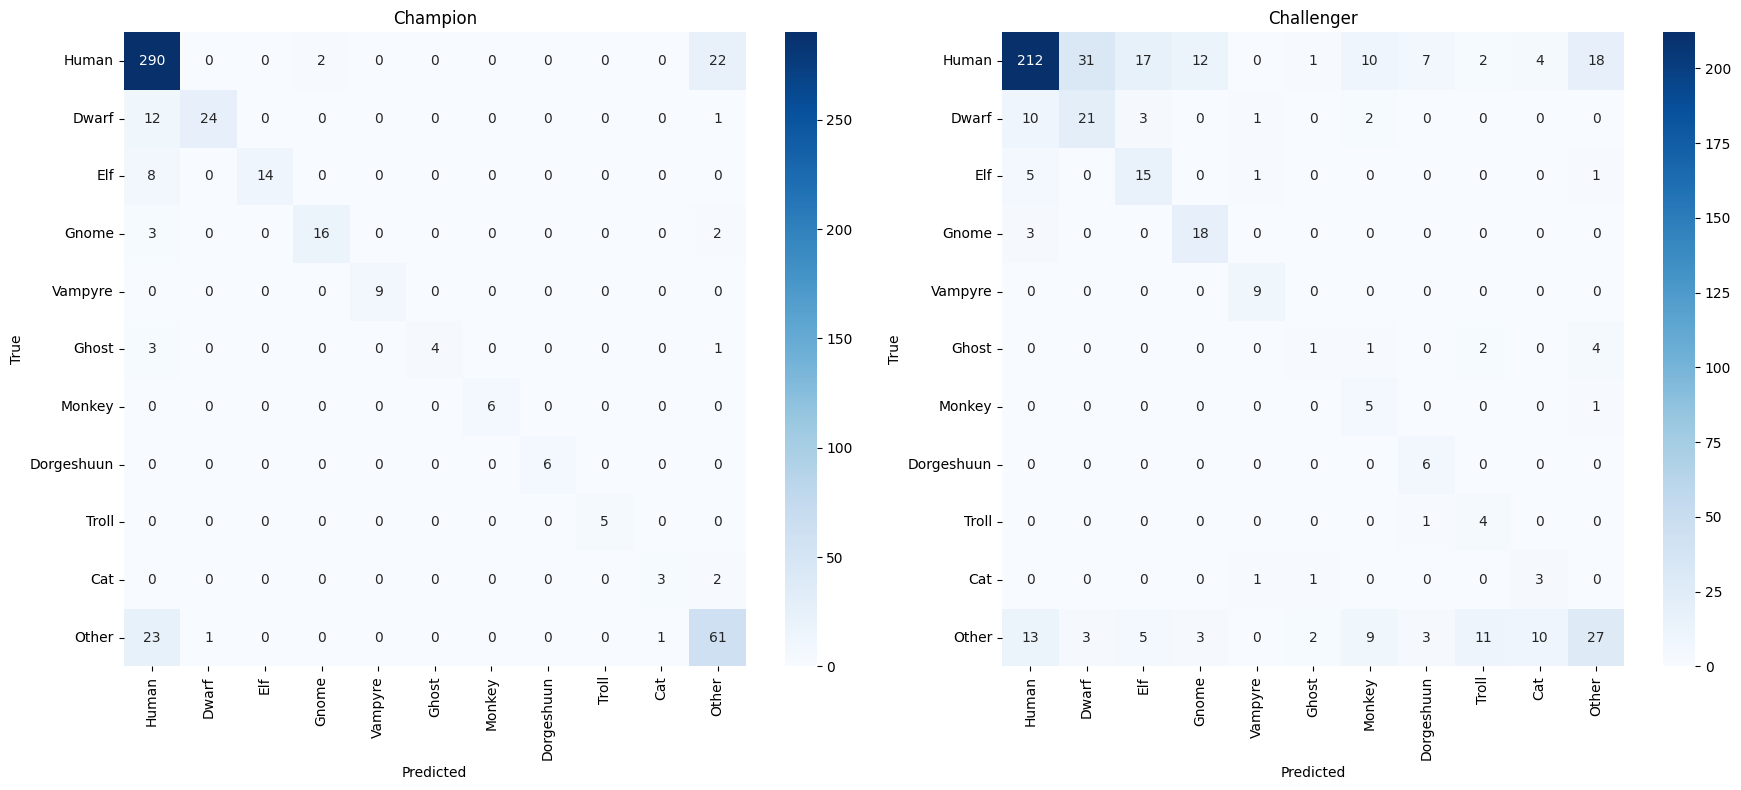

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (labels, preds, title) in zip(axes, [
    (champ_labels, champ_preds, "Champion"),
    (chal_labels, chal_preds, "Challenger"),
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
plt.tight_layout()
plt.savefig("../img/classification_confusion_matrices_side_by_side.png")
plt.show()

## Multiclass ROC / AUC (one-vs-rest)

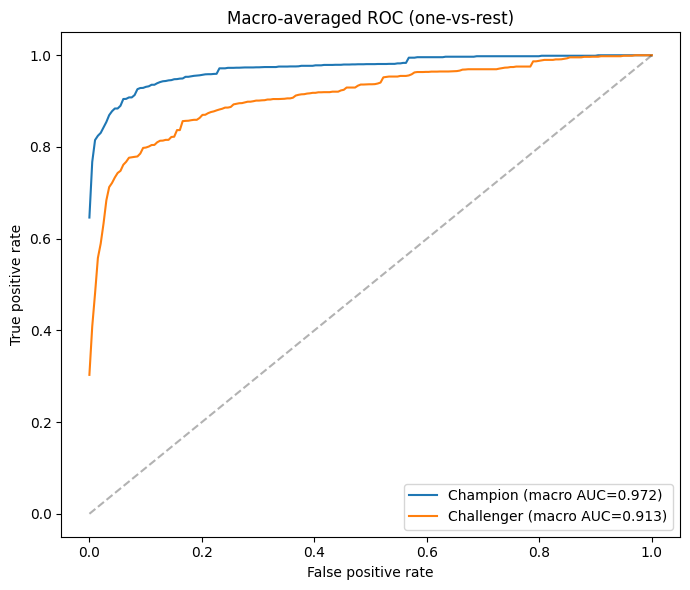

In [8]:
y_true_bin = label_binarize(champ_labels, classes=range(len(CLASS_NAMES)))

def macro_roc(y_true_bin, probs):
    fpr_grid = np.linspace(0, 1, 200)
    tprs = []
    aucs = []
    for i in range(y_true_bin.shape[1]):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        tprs.append(np.interp(fpr_grid, fpr, tpr))
        aucs.append(roc_auc_score(y_true_bin[:, i], probs[:, i]))
    return fpr_grid, np.mean(tprs, axis=0), np.mean(aucs)

champ_fpr, champ_tpr, champ_auc = macro_roc(y_true_bin, champ_probs)
chal_fpr, chal_tpr, chal_auc = macro_roc(y_true_bin, chal_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(champ_fpr, champ_tpr, label=f"Champion (macro AUC={champ_auc:.3f})")
ax.plot(chal_fpr, chal_tpr, label=f"Challenger (macro AUC={chal_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Macro-averaged ROC (one-vs-rest)")
ax.legend()
plt.tight_layout()
plt.savefig("../img/classification_roc_comparison.png")
plt.show()

## Model footprint: size, parameters, inference latency

In [9]:
footprint_df = pd.DataFrame([
    {
        "model": "Champion (pretrained ResNet18 x2)",
        "params": eu.count_params(champion),
        "checkpoint_MB": round(eu.model_size_mb("../data/npc_classifier.pth"), 2),
        "ms_per_image": round(eu.measure_inference_latency(champion, test_loader, DEVICE), 3),
    },
    {
        "model": "Challenger (from-scratch CNN x2)",
        "params": eu.count_params(challenger),
        "checkpoint_MB": round(eu.model_size_mb("../data/custom_cnn_classifier.pth"), 2),
        "ms_per_image": round(eu.measure_inference_latency(challenger, test_loader, DEVICE), 3),
    },
]).set_index("model")
footprint_df

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,params,checkpoint_MB,ms_per_image
model,,,
Champion (pretrained ResNet18 x2),22618251,86.44,1.260
Challenger (from-scratch CNN x2),3406347,13.04,0.952


## Summary

In [10]:
print("=== Classification: Champion vs. Challenger ===")
print(summary_df.round(4).to_string())
print()
print(footprint_df.to_string())
print()
print(f"Champion is {footprint_df.loc['Champion (pretrained ResNet18 x2)', 'params'] / footprint_df.loc['Challenger (from-scratch CNN x2)', 'params']:.1f}x more parameters than the challenger.")

=== Classification: Champion vs. Challenger ===
                                   accuracy  macro_f1  weighted_f1  macro_precision  macro_recall
model                                                                                            
Champion (pretrained ResNet18 x2)    0.8439    0.8447       0.8411           0.9218        0.7982
Challenger (from-scratch CNN x2)     0.6185    0.4731       0.6385           0.4163        0.6776

                                     params  checkpoint_MB  ms_per_image
model                                                                   
Champion (pretrained ResNet18 x2)  22618251          86.44         1.260
Challenger (from-scratch CNN x2)    3406347          13.04         0.952

Champion is 6.6x more parameters than the challenger.


## Pros / cons -- confirmed by the run above

**Champion -- pretrained ResNet18 x2 (transfer learning): test accuracy 0.844, macro F1 0.845**
- Confirmed: the ImageNet prior pays off most exactly where data is thinnest. The champion beats
  the challenger by its widest margins on Monkey (+0.70 F1, 6 test examples), Troll (+0.67 F1, 5
  examples), Ghost (+0.51 F1, 8 examples), and Dorgeshuun (+0.48 F1, 6 examples) -- the classes
  with the least training data. On Human (314 test examples, no shortage of data) the gap shrinks
  to +0.13 F1. This is exactly the transfer-learning value proposition: a pretrained visual prior
  substitutes for task-specific data.
- Con: 22.6M params, an 86.4MB checkpoint -- 6.6x larger than the challenger on both counts.
- Surprisingly not a con: despite 6.6x more parameters, GPU inference latency was only ~30%
  higher (1.26ms/image vs. 0.95ms/image) -- at this input resolution and batch size, the two
  ResNet18 backbones are not the bottleneck. The real deployment cost of the champion is model
  size/memory, not latency.

**Challenger -- from-scratch CNN x2: test accuracy 0.619, macro F1 0.473**
- Confirmed: needs far more data to reach comparable accuracy. It's respectable on Human
  (0.761 F1, 2,095 total examples) but degrades sharply on thin classes -- Ghost (0.154 F1),
  Monkey (0.303 F1), Cat (0.273 F1). Macro precision (0.416) trails macro recall (0.678),
  meaning it over-predicts several classes (likely Human/Other, the majority classes) rather
  than confidently discriminating the rare ones.
- Confirmed: needed 60 max epochs (vs. the champion's 20) and still early-stopped at epoch 31
  with a noisier, slower convergence curve (see `03b`'s training curves) -- consistent with
  learning a visual representation from scratch instead of fine-tuning one.
- Pro: 3.4M params, 13.0MB checkpoint -- meaningfully smaller and cheaper to store/version,
  though (per the latency numbers above) this doesn't translate into a decisive inference-speed
  win at this scale.
- Takeaway for the report: the champion-challenger gap is not uniform -- it's concentrated in
  the low-support classes, which is a stronger and more specific finding than "pretrained wins
  overall."